In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ecommerce_dataset (1).csv')
df.head()

,Order_ID,Order_Date,Customer_ID,Gender,Age,City,Product,Category,Price,Quantity,Payment_Method,Revenue
0,1001,2024-01-01,2102,Male,23,Port Harcourt,Laptop,Home Appliances,385589,1,Transfer,385589
1,1002,2024-01-02,2435,Female,35,Ibadan,Blender,Home Appliances,153892,4,Card,615568
2,1003,2024-01-03,2860,Female,22,Ibadan,Blender,Electronics,259717,4,Transfer,1038868
3,1004,2024-01-04,2270,Female,42,Kano,Laptop,Electronics,314167,2,Card,628334
4,1005,2024-01-05,2106,Female,19,Kano,Phone,Home Appliances,169654,2,Transfer,339308


In [3]:
print("shape of dataset:", df.shape)
print("\ncolumns in dataset:")
print(df.columns)

shape of dataset: (500, 12)

columns in dataset:
Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Gender', 'Age', 'City',
       'Product', 'Category', 'Price', 'Quantity', 'Payment_Method',
       'Revenue'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        500 non-null    int64 
 1   Order_Date      500 non-null    object
 2   Customer_ID     500 non-null    int64 
 3   Gender          500 non-null    object
 4   Age             500 non-null    int64 
 5   City            500 non-null    object
 6   Product         500 non-null    object
 7   Category        500 non-null    object
 8   Price           500 non-null    int64 
 9   Quantity        500 non-null    int64 
 10  Payment_Method  500 non-null    object
 11  Revenue         500 non-null    int64 
dtypes: int64(6), object(6)
memory usage: 47.0+ KB


In [5]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Gender            0
Age               0
City              0
Product           0
Category          0
Price             0
Quantity          0
Payment_Method    0
Revenue           0
dtype: int64

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        500 non-null    int64         
 1   Order_Date      500 non-null    datetime64[ns]
 2   Customer_ID     500 non-null    int64         
 3   Gender          500 non-null    object        
 4   Age             500 non-null    int64         
 5   City            500 non-null    object        
 6   Product         500 non-null    object        
 7   Category        500 non-null    object        
 8   Price           500 non-null    int64         
 9   Quantity        500 non-null    int64         
 10  Payment_Method  500 non-null    object        
 11  Revenue         500 non-null    int64         
dtypes: datetime64[ns](1), int64(6), object(5)
memory usage: 47.0+ KB


In [10]:
df['Month'] = df['Order_Date'].dt.month
df[['Order_Date', 'Month']].head()

,Order_Date,Month
0,2024-01-01,1
1,2024-01-02,1
2,2024-01-03,1
3,2024-01-04,1
4,2024-01-05,1


In [11]:
def age_group(age):
    if age < 25:
        return 'Young'
    elif age < 45:
        return 'Adult'
    else:
        return 'Senior'
df['Age_Group'] = df['Age'].apply(age_group)
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,23,Young
1,35,Adult
2,22,Young
3,42,Adult
4,19,Young


In [14]:
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Revenue'].dtype

dtype('int64')

In [15]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Gender            0
Age               0
City              0
Product           0
Category          0
Price             0
Quantity          0
Payment_Method    0
Revenue           0
month             0
Month             0
Age_Group         0
dtype: int64

In [16]:
df.head()

,Order_ID,Order_Date,Customer_ID,Gender,Age,City,Product,Category,Price,Quantity,Payment_Method,Revenue,month,Month,Age_Group
0,1001,2024-01-01,2102,Male,23,Port Harcourt,Laptop,Home Appliances,385589,1,Transfer,385589,1,1,Young
1,1002,2024-01-02,2435,Female,35,Ibadan,Blender,Home Appliances,153892,4,Card,615568,1,1,Adult
2,1003,2024-01-03,2860,Female,22,Ibadan,Blender,Electronics,259717,4,Transfer,1038868,1,1,Young
3,1004,2024-01-04,2270,Female,42,Kano,Laptop,Electronics,314167,2,Card,628334,1,1,Adult
4,1005,2024-01-05,2106,Female,19,Kano,Phone,Home Appliances,169654,2,Transfer,339308,1,1,Young


In [18]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 334811644


In [20]:
total_quantity = df['Quantity'].sum()
print("Total Quantity Sold:", total_quantity)
                                    

Total Quantity Sold: 1221


In [23]:
revenue_by_category = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
revenue_by_category

Category
Home Appliances    171354719
Electronics        163456925
Name: Revenue, dtype: int64

In [24]:
revenue_by_city =df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
revenue_by_city

City
Kano             75090540
Port Harcourt    73663690
Ibadan           63441485
Abuja            62484807
Lagos            60131122
Name: Revenue, dtype: int64

In [27]:
monthly_sales =df.groupby('Month')['Revenue'].sum().sort_index()
monthly_sales                       

Month
1     45154848
2     41221160
3     38045285
4     41682186
5     30243973
6     22313943
7     17105310
8     18468783
9     18309097
10    16626182
11    18605298
12    27035579
Name: Revenue, dtype: int64

In [28]:
top_5_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)
top_5_products

Product
Phone      74734921
Blender    71746523
Fridge     67390132
Laptop     64980917
TV         55959151
Name: Revenue, dtype: int64

In [29]:
gender_spending = df.groupby('Gender')['Revenue'].mean().sort_values(ascending=False)
gender_spending

Gender
Female    670696.111111
Male      668533.161290
Name: Revenue, dtype: float64

In [30]:
payment_method = df['Payment_Method'].value_counts()
payment_method

Payment_Method
Card        173
Transfer    167
Cash        160
Name: count, dtype: int64

In [31]:
age_spending = df.groupby('Age')['Revenue'].mean()
age_spending.head(10)

Age
18    632024.687500
19    764910.000000
20    787264.000000
21    904694.538462
22    850005.411765
23    617046.250000
24    428427.142857
25    693591.133333
26    462311.888889
27    436438.533333
Name: Revenue, dtype: float64

In [32]:
highest_product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(1)
highest_product

Product
Phone    74734921
Name: Revenue, dtype: int64

In [35]:
top_city = df.groupby('City')['Revenue'].sum().sort_values(ascending=False).head(1)
top_city

City
Kano    75090540
Name: Revenue, dtype: int64

In [36]:
best_month = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False).head(1)
best_month

Month
1    45154848
Name: Revenue, dtype: int64

In [37]:
df.groupby('Category')['Revenue'].sum()

Category
Electronics        163456925
Home Appliances    171354719
Name: Revenue, dtype: int64

In [38]:
df[df['Category'].isin(['Electronic','Home Appliance'])].groupby('Category')['Revenue'].sum()


Series([], Name: Revenue, dtype: int64)

In [39]:
df.groupby('Gender')['Revenue'].mean().sort_values(ascending=False)

Gender
Female    670696.111111
Male      668533.161290
Name: Revenue, dtype: float64

In [41]:
df['Payment_Method'].value_counts().head(1)

Payment_Method
Card    173
Name: count, dtype: int64

In [42]:
df[['Age','Revenue']].corr()

,Age,Revenue
Age,1.000000,-0.038184
Revenue,-0.038184,1.000000


In [44]:
df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

Product
Phone      74734921
Blender    71746523
Fridge     67390132
Laptop     64980917
TV         55959151
Name: Revenue, dtype: int64

In [45]:
df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

Product
Phone      273
Blender    270
Laptop     240
Fridge     237
TV         201
Name: Quantity, dtype: int64

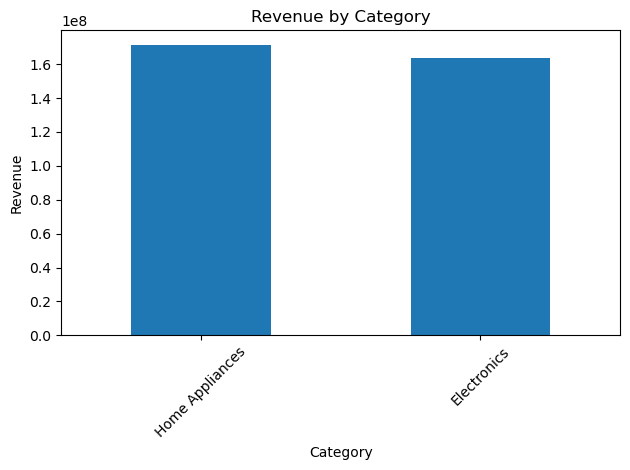

In [93]:
revenue_by_category.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/revenue_by_category.png')
plt.show()

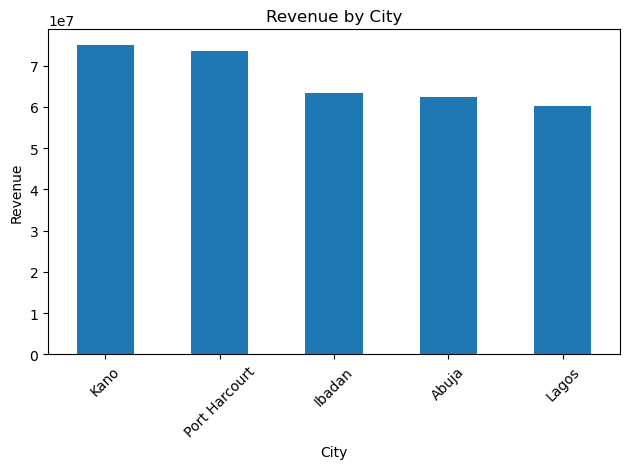

In [92]:
revenue_by_city.plot(kind='bar')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/revenue_by_city.png')
plt.show()

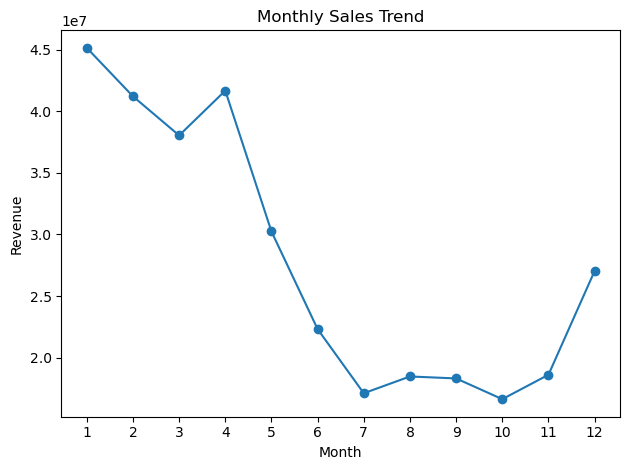

In [88]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(monthly_sales.index)
plt.tight_layout()
plt.savefig('images/monthly_sales_trend.png')
plt.show()

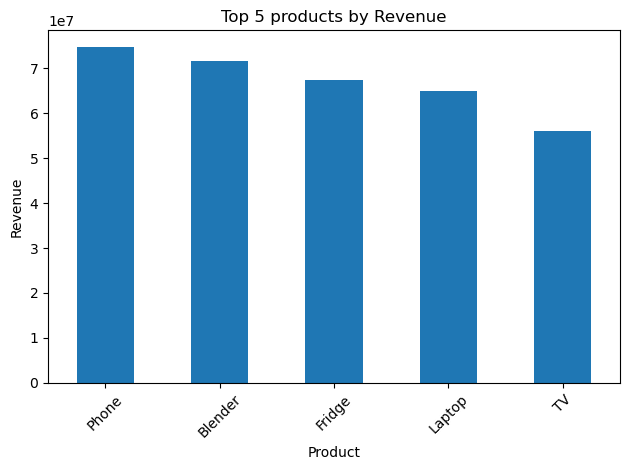

In [89]:
top_5_products.plot(kind='bar')
plt.title('Top 5 products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/top_5_products.png')
plt.show()
    

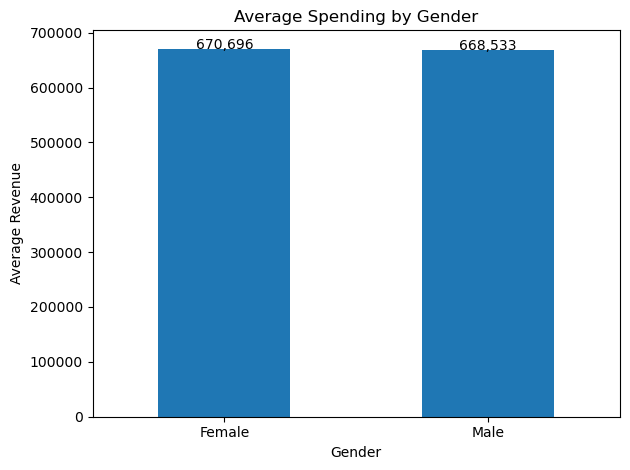

In [67]:
gender_spending.plot(kind='bar')
ax = gender_spending.plot(kind='bar')
for i, v in enumerate(gender_spending):
    ax.text(i, v, f"{v:,.0f}", ha='center')
plt.title('Average Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

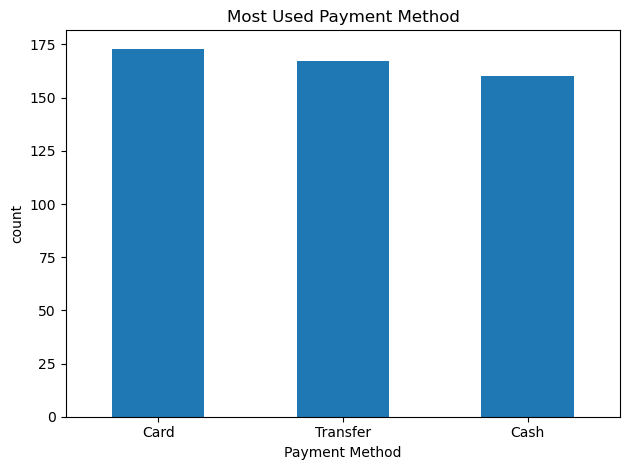

In [83]:
payment_method.plot(kind='bar')
plt.title('Most Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/payment_method.png')
plt.show()

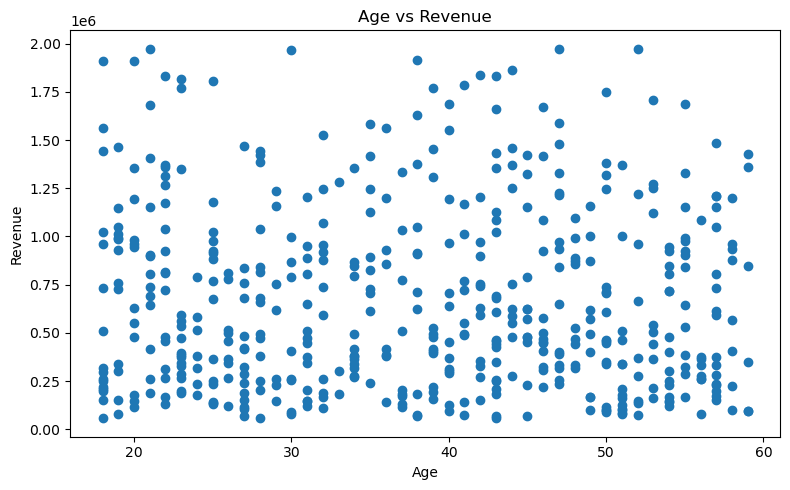

In [82]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Revenue'])
plt.title('Age vs Revenue')
plt.xlabel('Age')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('images/age_vs_revenue.png')
plt.show()

In [ ]:
print("Total Revenue:",total_revenue)
print("Total Quantity Sold:",total_quantity)

print("\nRevenue by Category:")
print(revenue_by_category)

print("\nRevenue by City:")
print(revenue_by_city)

print("\nMonthly Sales Trend:")
print(monthly_sales)

print("\nTop 5 Products by Revenue:")
print(top_5_products)

print("\nAverage Spending by Gender:")
print(gender_spending)

print("\nMost Used Payment Method:")
print(payment_method)

In [59]:
df. groupby('Gender')['Revenue'].mean()

Gender
Female    670696.111111
Male      668533.161290
Name: Revenue, dtype: float64

In [62]:
df['Payment_Method'].value_counts()

Payment_Method
Card        173
Transfer    167
Cash        160
Name: count, dtype: int64

In [58]:
df.to_csv('cleaned_ecommerce_dataset.csv', index=False)